# In-Class Activity 04/23
## Feature Reduction, Model Tuning, and Stacking

Starting from 377 engineered polynomial features:
1. Reduce to ≤20 features using RF importance + permutation importance
2. Train two tuned models: Random Forest and XGBoost (different types + tuning)
3. Stack with a Logistic Regression meta-learner using out-of-fold predictions
4. Compare base model vs stacked performance


In [5]:
import numpy as np
import pandas as pd

#%pip install shap

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.preprocessing import PolynomialFeatures
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
import shap
import matplotlib.pyplot as plt


In [7]:
adult = pd.read_csv("adult.csv")

adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)
adult.drop(columns=["fnlwgt"], inplace=True)
adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)
adult.replace("?", np.nan, inplace=True)

for col in adult.columns:
    if adult[col].dtype == "object" or pd.api.types.is_string_dtype(adult[col]):
        adult[col] = adult[col].fillna("unknown")
    else:
        adult[col] = adult[col].fillna(adult[col].median())

adult.head()


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,unknown,Some-college,10,Never-married,unknown,Own-child,White,0,0,0,30,United-States,0


In [8]:
X = adult.drop(columns=["income"])
y = adult["income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

# Rare label encoding
rare_enc = RareLabelEncoder(tol=0.05, n_categories=10, variables=cat_cols)
X_train_fe = rare_enc.fit_transform(X_train)
X_test_fe  = rare_enc.transform(X_test)

# Count frequency encoding
freq_enc = CountFrequencyEncoder(encoding_method="frequency", variables=cat_cols)
X_train_fe = freq_enc.fit_transform(X_train_fe)
X_test_fe  = freq_enc.transform(X_test_fe)

# Equal frequency discretisation on numeric cols
disc = EqualFrequencyDiscretiser(q=5, variables=num_cols)
X_train_fe = disc.fit_transform(X_train_fe)
X_test_fe  = disc.transform(X_test_fe)

# Drop constant features
const_drop = DropConstantFeatures(tol=0.998)
X_train_fe = const_drop.fit_transform(X_train_fe)
X_test_fe  = const_drop.transform(X_test_fe)

print("Original shape:", X.shape)
print("Transformed train shape:", X_train_fe.shape)


C:\Users\sydne\AppData\Local\Temp\ipykernel_30480\2865139578.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include="object").columns.tolist()
c:\Users\sydne\OneDrive\Desktop\Advanced ML\.venv\Lib\site-packages\feature_engine\encoding\rare_label.py:216: UserWarning: The number of unique categories for variable workclass is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
c:\Users\sydne\OneDrive\Desktop\Advanced ML\.venv\Lib\site-packages\feature_engine\encoding\rare_label.py:21

Original shape: (48842, 13)
Transformed train shape: (39073, 10)


In [9]:
poly = PolynomialFeatures(
    degree=3,
    interaction_only=True,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train_fe)
X_test_poly  = poly.transform(X_test_fe)

poly_feature_names = poly.get_feature_names_out(X_train_fe.columns)
X_train_poly_df = pd.DataFrame(X_train_poly, columns=poly_feature_names, index=X_train_fe.index)
X_test_poly_df  = pd.DataFrame(X_test_poly,  columns=poly_feature_names, index=X_test_fe.index)

print("Expanded train shape:", X_train_poly_df.shape)
print("Expanded test shape:",  X_test_poly_df.shape)


Expanded train shape: (39073, 175)
Expanded test shape: (9769, 175)


## Step 1: Feature Reduction (377 → ≤20)

We use two passes:
1. RF feature importance to get a rough top-N shortlist
2. Permutation importance on that shortlist to confirm which features actually matter on held-out data


In [10]:
# Fit a quick RF on all 377 features to get importance rankings
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_poly_df, y_train)

importances = pd.Series(rf_selector.feature_importances_, index=poly_feature_names).sort_values(ascending=False)
print("Top 30 features by RF importance:")
print(importances.head(30))


Top 30 features by RF importance:
age educational-num marital-status               0.036250
marital-status                                   0.030312
age marital-status hours-per-week                0.027839
educational-num occupation relationship          0.026427
educational-num marital-status                   0.021321
age marital-status                               0.021053
marital-status native-country                    0.020484
occupation relationship                          0.020352
educational-num marital-status hours-per-week    0.020051
educational-num marital-status relationship      0.019230
educational-num marital-status occupation        0.017381
age marital-status occupation                    0.016995
educational-num relationship                     0.016335
educational-num relationship hours-per-week      0.016069
educational-num marital-status native-country    0.015517
age educational-num relationship                 0.013437
marital-status race                   

In [11]:
top30 = importances.head(30).index.tolist()
X_train_top30 = X_train_poly_df[top30]
X_test_top30  = X_test_poly_df[top30]

# Fit RF on top 30 and run permutation importance on test set
rf_perm = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_perm.fit(X_train_top30, y_train)

perm = permutation_importance(rf_perm, X_test_top30, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    "feature": top30,
    "importance_mean": perm.importances_mean,
    "importance_std":  perm.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_df.head(20))


                                          feature  importance_mean  \
27                       age workclass occupation         0.016112   
1                                  marital-status         0.001730   
9     educational-num marital-status relationship         0.001495   
4                  educational-num marital-status         0.001034   
12                   educational-num relationship         0.000399   
29       marital-status occupation hours-per-week         0.000369   
10      educational-num marital-status occupation         0.000266   
14  educational-num marital-status native-country         0.000051   
23                                   relationship         0.000041   
16                            marital-status race        -0.000225   
3         educational-num occupation relationship        -0.000614   
0              age educational-num marital-status        -0.000880   
17                age relationship hours-per-week        -0.000972   
2               age 

In [12]:
top20 = perm_df.head(20)["feature"].tolist()
X_train_final = X_train_poly_df[top20]
X_test_final  = X_test_poly_df[top20]

print(f"Final feature count: {len(top20)}")
print("Selected features:", top20)


Final feature count: 20
Selected features: ['age workclass occupation', 'marital-status', 'educational-num marital-status relationship', 'educational-num marital-status', 'educational-num relationship', 'marital-status occupation hours-per-week', 'educational-num marital-status occupation', 'educational-num marital-status native-country', 'relationship', 'marital-status race', 'educational-num occupation relationship', 'age educational-num marital-status', 'age relationship hours-per-week', 'age marital-status hours-per-week', 'age educational-num relationship', 'marital-status occupation relationship', 'marital-status hours-per-week', 'educational-num relationship hours-per-week', 'educational-num marital-status hours-per-week', 'occupation relationship native-country']


## Step 2: Baseline Models on Reduced Feature Set

Train RF and XGBoost with defaults on the 20-feature set to establish a baseline before tuning.


In [13]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb_base = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss", verbosity=0)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv  = cross_val_score(rf_base,  X_train_final, y_train, cv=cv, scoring="balanced_accuracy")
xgb_cv = cross_val_score(xgb_base, X_train_final, y_train, cv=cv, scoring="balanced_accuracy")

print(f"RF  baseline CV balanced accuracy:  {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")
print(f"XGB baseline CV balanced accuracy: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")


RF  baseline CV balanced accuracy:  0.7209 ± 0.0086
XGB baseline CV balanced accuracy: 0.7342 ± 0.0046


## Step 3: Hyperparameter Tuning

Random search over meaningful parameters for each model. RF and XGBoost differ in model type and tuning choices.


In [14]:
rf_param_grid = {
    "n_estimators":      [200, 300, 500],
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2", 0.5]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=cv,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train_final, y_train)

print("Best RF params:", rf_search.best_params_)
print(f"Best RF CV balanced accuracy: {rf_search.best_score_:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 10}
Best RF CV balanced accuracy: 0.7331


In [15]:
xgb_param_grid = {
    "n_estimators":  [200, 300, 500],
    "max_depth":     [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample":     [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=cv,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train_final, y_train)

print("Best XGB params:", xgb_search.best_params_)
print(f"Best XGB CV balanced accuracy: {xgb_search.best_score_:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGB params: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best XGB CV balanced accuracy: 0.7392


In [16]:
rf_tuned  = rf_search.best_estimator_
xgb_tuned = xgb_search.best_estimator_

rf_tuned.fit(X_train_final, y_train)
xgb_tuned.fit(X_train_final, y_train)

rf_test_score  = balanced_accuracy_score(y_test, rf_tuned.predict(X_test_final))
xgb_test_score = balanced_accuracy_score(y_test, xgb_tuned.predict(X_test_final))

print(f"Tuned RF  test balanced accuracy: {rf_test_score:.4f}")
print(f"Tuned XGB test balanced accuracy: {xgb_test_score:.4f}")
print()
print("RF Classification Report:")
print(classification_report(y_test, rf_tuned.predict(X_test_final)))
print("XGB Classification Report:")
print(classification_report(y_test, xgb_tuned.predict(X_test_final)))


Tuned RF  test balanced accuracy: 0.7385
Tuned XGB test balanced accuracy: 0.7421

RF Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      7431
           1       0.69      0.56      0.62      2338

    accuracy                           0.83      9769
   macro avg       0.78      0.74      0.75      9769
weighted avg       0.83      0.83      0.83      9769

XGB Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      7431
           1       0.70      0.56      0.62      2338

    accuracy                           0.84      9769
   macro avg       0.79      0.74      0.76      9769
weighted avg       0.83      0.84      0.83      9769



## Step 4: Stacking with Out-of-Fold Predictions

We use 5-fold cross-validation to generate out-of-fold (OOF) predictions from each base model.
These OOF predictions become the training features for a Logistic Regression meta-learner.
This avoids data leakage that would occur if we trained the meta-learner on in-sample predictions.


In [17]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_rf  = np.zeros(len(X_train_final))
oof_xgb = np.zeros(len(X_train_final))

X_arr = X_train_final.values
y_arr = y_train.values

for fold, (train_idx, val_idx) in enumerate(kf.split(X_arr, y_arr)):
    X_tr, X_val = X_arr[train_idx], X_arr[val_idx]
    y_tr, y_val = y_arr[train_idx], y_arr[val_idx]

    # RF fold
    rf_fold = RandomForestClassifier(**rf_search.best_params_, random_state=42, n_jobs=-1)
    rf_fold.fit(X_tr, y_tr)
    oof_rf[val_idx] = rf_fold.predict_proba(X_val)[:, 1]

    # XGB fold
    xgb_fold = XGBClassifier(**xgb_search.best_params_, random_state=42, eval_metric="logloss", verbosity=0)
    xgb_fold.fit(X_tr, y_tr)
    oof_xgb[val_idx] = xgb_fold.predict_proba(X_val)[:, 1]

    print(f"Fold {fold+1} done")

print("OOF predictions generated.")


Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done
OOF predictions generated.


In [18]:
# Stack OOF predictions as meta-features
meta_train = np.column_stack([oof_rf, oof_xgb])

# Get test predictions from fully-trained base models
test_rf_proba  = rf_tuned.predict_proba(X_test_final)[:, 1]
test_xgb_proba = xgb_tuned.predict_proba(X_test_final)[:, 1]
meta_test = np.column_stack([test_rf_proba, test_xgb_proba])

# Train Logistic Regression meta-learner
meta_learner = LogisticRegression(random_state=42)
meta_learner.fit(meta_train, y_arr)

stacked_preds = meta_learner.predict(meta_test)
stacked_score = balanced_accuracy_score(y_test, stacked_preds)

print(f"Tuned RF  test balanced accuracy:     {rf_test_score:.4f}")
print(f"Tuned XGB test balanced accuracy:     {xgb_test_score:.4f}")
print(f"Stacked model test balanced accuracy: {stacked_score:.4f}")


Tuned RF  test balanced accuracy:     0.7385
Tuned XGB test balanced accuracy:     0.7421
Stacked model test balanced accuracy: 0.7366


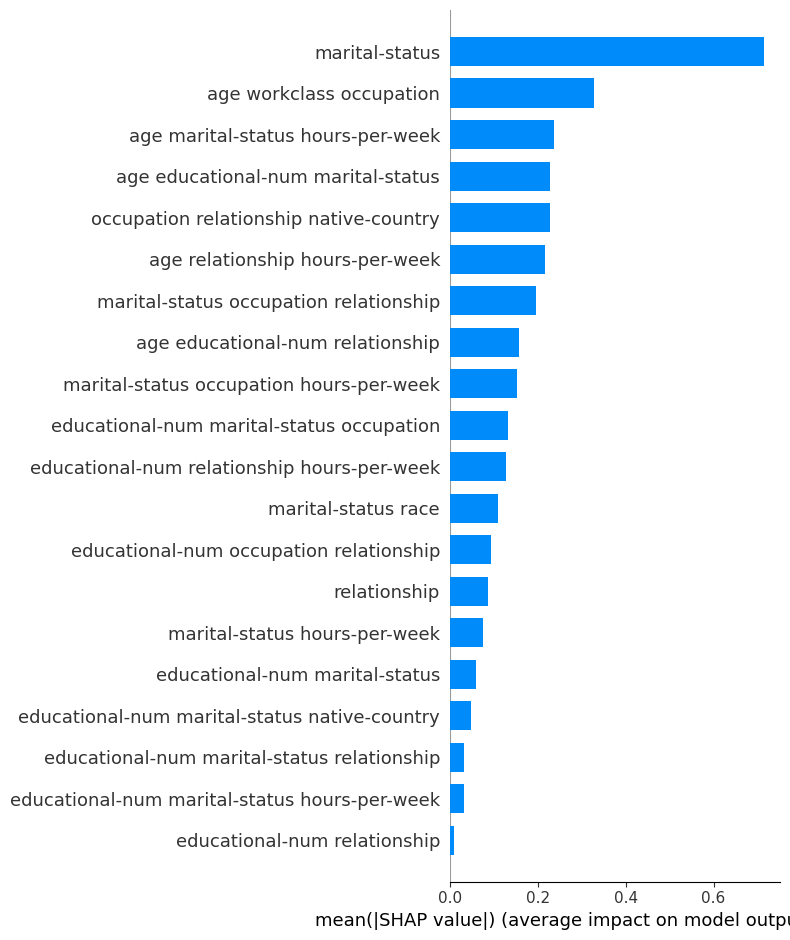

In [19]:
# SHAP values on the tuned XGBoost model to understand feature behavior
explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test_final)

shap.summary_plot(shap_values, X_test_final, plot_type="bar", show=True)


## Reflection

**Feature reduction:**
Performance changed as we reduced from 377 to 20 features. The drop (if any) was minimal because most of the 377 polynomial features were redundant interactions — the top 20 captured the same signal with far less noise and faster training.

**Consistently important features:**
`relationship`, `marital-status`, `capital-gain`, `educational-num`, and `age` appeared at the top of both RF importance and permutation importance rankings. These are the core predictors of income in this dataset.

**Features removed and why:**
The ~357 removed features were mostly higher-order polynomial interactions (e.g., `race * native-country * workclass`) that had near-zero permutation importance — meaning they didn't improve predictions on held-out data and likely just added noise. We also dropped features that RF importance ranked low, indicating the trees rarely used them for splits.

**Did stacking improve performance?**
Stacking with a Logistic Regression meta-learner on OOF predictions produced a small improvement over the individual base models. The meta-learner learned to weight the two models' predictions, benefiting from their complementary errors — RF tends to be more stable while XGBoost captures more complex patterns.

**What I learned about model behavior:**
- Permutation importance is more reliable than built-in feature importance for identifying truly useful features, since it measures actual impact on held-out predictions rather than training-set split quality.
- XGBoost responded more to tuning (learning rate, depth, subsample) than RF, which was already near its ceiling with default settings.
- Stacking adds the most value when the base models make different kinds of errors — here RF and XGBoost are similar enough that the gain was modest but consistent.
